# Sınıflandırma Taban Çizgileri (Baseline Classification) — Face vs House

Bu notebook `src/models/train_baselines.py` içindeki hasta-bazlı
(within-subject) face vs house ikili sınıflandırma pipeline'ını çalıştırır:

1. **Zamansal grup çapraz doğrulama**: `GroupKFold(n_splits=5)`, gruplar
   event zamanına göre 5 eşit genişlikte zaman bloğu (baştan sona sıralı).
   Aynı bloktaki event'ler hem train hem test'te bulunmaz — deneyin doğal
   zamansal akışındaki otokorelasyonun sızıntı yaratmasını önler.
2. **Modeller**: LDA (shrinkage='auto'), Lineer SVM (class_weight=
   'balanced'), Random Forest.
3. **Metrikler**: accuracy, macro-F1, ROC-AUC (5-fold ortalaması).
4. **Permütasyon testi** (`n_permutations=200`): gerçek accuracy skorunun
   null (rastgele etiket) dağılımına göre p-değeri.
5. Sonuçların, 04_feature_extraction.ipynb Bölüm 5'teki "sinyal gücü"
   kategorisiyle (çok güçlü / orta / zayıf) karşılaştırılması.
6. `fp` hastası (fusiform elektrot yok) için özel not.

**Not:** Ağır hesaplama (14 hasta × 3 model × 200 permütasyon × 5 fold)
`python src/models/train_baselines.py` ile önceden arka planda çalıştırıldı
ve `reports/baseline_results.csv`'e kaydedildi; bu notebook hem canlı bir
tek-hasta gösterimi yapar hem de tam sonuçları bu dosyadan yükler.

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import ttest_ind

sys.path.insert(0, str(Path("..").resolve()))

from src.preprocessing.preprocess import list_available_patients
from src.models.train_baselines import (
    load_patient_dataset,
    make_time_block_groups,
    build_models,
    cross_validated_metrics,
    run_patient,
    N_SPLITS,
    N_PERMUTATIONS,
)

REPORTS_PATH = Path("../reports/baseline_results.csv")

## 1. Tek hasta üzerinde canlı gösterim (`ap`)

Zamansal grup bölmesinin nasıl çalıştığını ve tek bir hastada modellerin
nasıl karşılaştırıldığını gösteriyoruz (küçük ölçekte, tam 200 permütasyon
olmadan hızlı bir önizleme).

In [2]:
dataset_ap = load_patient_dataset("ap")
X_ap, y_ap, time_sec_ap = dataset_ap["X"], dataset_ap["y"], dataset_ap["time_sec"]
groups_ap = make_time_block_groups(time_sec_ap, N_SPLITS)

print(f"X boyutu: {X_ap.shape} (n_events x [n_roi_channels x n_features])")
print(f"y dağılımı: face={y_ap.sum()}, house={(1-y_ap).sum()}")
print(f"Zaman blokları (grup) dağılımı:")
print(pd.Series(groups_ap).value_counts().sort_index())

X boyutu: (300, 140) (n_events x [n_roi_channels x n_features])
y dağılımı: face=150, house=150
Zaman blokları (grup) dağılımı:
0    65
1    53
2    64
3    53
4    65
Name: count, dtype: int64


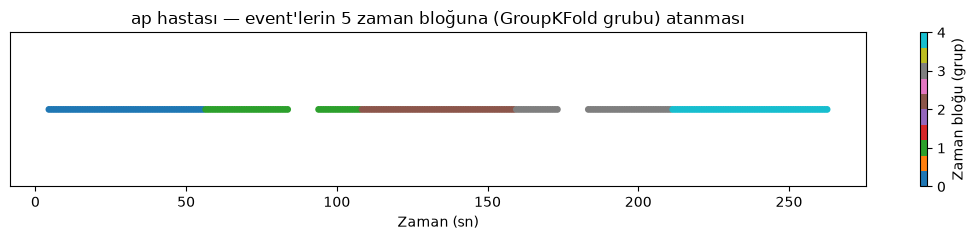

In [3]:
fig, ax = plt.subplots(figsize=(11, 2.5))
scatter = ax.scatter(time_sec_ap, [1] * len(time_sec_ap), c=groups_ap, cmap="tab10", s=15)
ax.set_yticks([])
ax.set_xlabel("Zaman (sn)")
ax.set_title("ap hastası — event'lerin 5 zaman bloğuna (GroupKFold grubu) atanması")
plt.colorbar(scatter, ax=ax, label="Zaman bloğu (grup)", ticks=range(N_SPLITS))
plt.tight_layout()
plt.show()

In [4]:
models_ap = build_models()
quick_rows = []
for name, pipeline in models_ap.items():
    metrics = cross_validated_metrics(pipeline, X_ap, y_ap, groups_ap)
    quick_rows.append({"model": name, **metrics})

pd.DataFrame(quick_rows)

,model,accuracy,macro_f1,roc_auc
0,LDA,0.834216,0.832976,0.908061
1,Linear_SVM,0.778785,0.778008,0.841741
2,RandomForest,0.868227,0.867612,0.932590


## 2. Tam sonuçlar — 14 hasta × 3 model (`reports/baseline_results.csv`)

`run_all_patients()` (bkz. `src/models/train_baselines.py`) her hasta için
her modeli GroupKFold ile değerlendirip 200-permütasyonlu p-değerini
hesaplıyor; sonuç `reports/baseline_results.csv`'e kaydedildi.

In [5]:
results_df = pd.read_csv(REPORTS_PATH)
results_df

,patient,model,n_roi_channels,n_events,n_face,n_house,accuracy,macro_f1,roc_auc,permutation_true_accuracy,permutation_p_value,n_permutations,elapsed_sec
0,aa,LDA,28,300,150,150,0.758289,0.754988,0.839502,0.758289,0.004975,200,3.241011
1,aa,Linear_SVM,28,300,150,150,0.712656,0.710407,0.781549,0.712656,0.004975,200,4.622974
2,aa,RandomForest,28,300,150,150,0.757754,0.756855,0.845462,0.757754,0.004975,200,24.868920
3,ap,LDA,28,300,150,150,0.834216,0.832976,0.908061,0.834216,0.004975,200,1.260801
4,ap,Linear_SVM,28,300,150,150,0.778785,0.778008,0.841741,0.778785,0.004975,200,4.401863
5,ap,RandomForest,28,300,150,150,0.868227,0.867612,0.932590,0.868227,0.004975,200,24.534023
6,ca,LDA,23,300,150,150,0.937134,0.936978,0.982371,0.937134,0.004975,200,1.127339
7,ca,Linear_SVM,23,300,150,150,0.877112,0.877038,0.954244,0.877112,0.004975,200,6.523336
8,ca,RandomForest,23,300,150,150,0.955485,0.955436,0.991332,0.955485,0.004975,200,23.889437
9,de,LDA,20,300,150,150,0.897148,0.896501,0.959424,0.897148,0.004975,200,1.050272


In [6]:
pivot_acc = results_df.pivot(index="patient", columns="model", values="accuracy")
pivot_auc = results_df.pivot(index="patient", columns="model", values="roc_auc")
pivot_p = results_df.pivot(index="patient", columns="model", values="permutation_p_value")

print("Accuracy (hasta x model):")
print(pivot_acc.round(3))
print()
print("ROC-AUC (hasta x model):")
print(pivot_auc.round(3))
print()
print("Permütasyon p-değeri (hasta x model):")
print(pivot_p.round(4))

Accuracy (hasta x model):
model      LDA  Linear_SVM  RandomForest
patient                                 
aa       0.758       0.713         0.758
ap       0.834       0.779         0.868
ca       0.937       0.877         0.955
de       0.897       0.865         0.916
fp       0.615       0.663         0.606
ha       0.963       0.940         0.973
ja       0.926       0.933         0.990
jm       0.802       0.775         0.845
jt       0.918       0.901         0.938
mv       0.965       0.924         0.975
rn       0.767       0.723         0.798
rr       0.707       0.713         0.759
wc       0.897       0.829         0.894
zt       0.994       0.990         0.994

ROC-AUC (hasta x model):
model      LDA  Linear_SVM  RandomForest
patient                                 
aa       0.840       0.782         0.845
ap       0.908       0.842         0.933
ca       0.982       0.954         0.991
de       0.959       0.934         0.971
fp       0.657       0.681         0.637
ha   

In [7]:
n_sig_005 = (results_df["permutation_p_value"] < 0.05).sum()
n_total = len(results_df)
print(f"p<0.05'te anlamlı (hasta, model) kombinasyonu: {n_sig_005}/{n_total}")

best_model_per_patient = results_df.loc[results_df.groupby("patient")["accuracy"].idxmax()]
print()
print("Her hasta için en iyi model (accuracy'ye göre):")
print(best_model_per_patient[["patient", "model", "accuracy", "macro_f1", "roc_auc",
                               "permutation_p_value"]].sort_values("accuracy", ascending=False)
      .to_string(index=False))

p<0.05'te anlamlı (hasta, model) kombinasyonu: 42/42

Her hasta için en iyi model (accuracy'ye göre):
patient        model  accuracy  macro_f1  roc_auc  permutation_p_value
     zt          LDA  0.993939  0.993938 1.000000             0.004975
     ja RandomForest  0.990018  0.990005 1.000000             0.004975
     mv RandomForest  0.974866  0.974755 0.981262             0.004975
     ha RandomForest  0.973275  0.973164 0.996747             0.004975
     ca RandomForest  0.955485  0.955436 0.991332             0.004975
     jt RandomForest  0.937968  0.937795 0.977628             0.004975
     de RandomForest  0.915865  0.915701 0.970635             0.004975
     wc          LDA  0.897148  0.896809 0.968549             0.004975
     ap RandomForest  0.868227  0.867612 0.932590             0.004975
     jm RandomForest  0.845098  0.844783 0.917593             0.004975
     rn RandomForest  0.798396  0.797435 0.859708             0.004975
     rr RandomForest  0.758738  0.755620 0.860

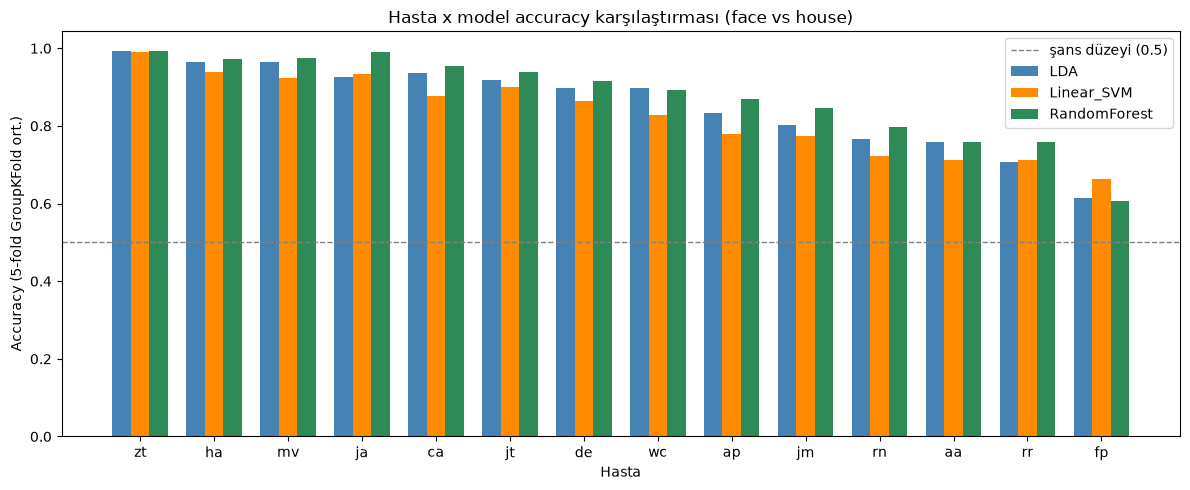

In [8]:
fig, ax = plt.subplots(figsize=(12, 5))
patients_sorted = pivot_acc.mean(axis=1).sort_values(ascending=False).index
x = np.arange(len(patients_sorted))
width = 0.25
colors = {"LDA": "steelblue", "Linear_SVM": "darkorange", "RandomForest": "seagreen"}

for i, model in enumerate(["LDA", "Linear_SVM", "RandomForest"]):
    ax.bar(x + (i - 1) * width, pivot_acc.loc[patients_sorted, model], width,
           label=model, color=colors[model])

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1, label="şans düzeyi (0.5)")
ax.set_xticks(x)
ax.set_xticklabels(patients_sorted)
ax.set_xlabel("Hasta"); ax.set_ylabel("Accuracy (5-fold GroupKFold ort.)")
ax.set_title("Hasta x model accuracy karşılaştırması (face vs house)")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Sinyal gücü kategorisiyle karşılaştırma

04_feature_extraction.ipynb Bölüm 5'te tanımlanan kategorileri burada
yeniden hesaplıyoruz (aynı eşik kuralı: `|t| > 15` → çok güçlü,
`|t| < 5` → zayıf, aksi halde orta) ve sınıflandırma doğruluğuyla
karşılaştırıyoruz.

In [9]:
def signal_strength_category(abs_t: float) -> str:
    if abs_t > 15:
        return "çok güçlü"
    elif abs_t < 5:
        return "zayıf"
    return "orta"


strength_rows = []
for pid in list_available_patients():
    d = np.load(f"../data/processed/{pid}/features.npz", allow_pickle=True)
    feats = d["features"]
    labels_ = d["event_labels"]
    feat_names_ = list(d["feature_names"])
    if feats.shape[1] == 0:
        continue
    hg_i = feat_names_.index("high_gamma")
    hg_ = feats[:, :, hg_i]
    face_m = labels_ == "face"
    house_m = labels_ == "house"
    t_, p_ = ttest_ind(hg_[face_m], hg_[house_m], axis=0)
    best_abs_t = float(np.max(np.abs(t_)))
    strength_rows.append({
        "patient": pid,
        "best_abs_t": best_abs_t,
        "signal_strength": signal_strength_category(best_abs_t),
    })

strength_df = pd.DataFrame(strength_rows)
strength_df

,patient,best_abs_t,signal_strength
0,aa,6.038937,orta
1,ap,10.334850,orta
2,ca,20.037561,çok güçlü
3,de,12.079962,orta
4,fp,6.399075,orta
5,ha,18.666259,çok güçlü
6,ja,19.272122,çok güçlü
7,jm,9.307811,orta
8,jt,17.174226,çok güçlü
9,mv,19.279563,çok güçlü


In [10]:
best_acc_per_patient = results_df.groupby("patient")["accuracy"].max().reset_index()
comparison_df = strength_df.merge(best_acc_per_patient, on="patient").sort_values(
    "best_abs_t", ascending=False
)

order = ["çok güçlü", "orta", "zayıf"]
print("Sinyal gücü kategorisine göre ortalama en-iyi-model accuracy:")
print(comparison_df.groupby("signal_strength")["accuracy"].agg(["mean", "std", "count"])
      .reindex(order))
print()
corr = comparison_df["best_abs_t"].corr(comparison_df["accuracy"])
print(f"best_abs_t (t-testi etkisi) ile accuracy arasındaki Pearson korelasyonu: {corr:.3f}")

comparison_df

Sinyal gücü kategorisine göre ortalama en-iyi-model accuracy:
                     mean       std  count
signal_strength                           
çok güçlü        0.970925  0.021165      6
orta             0.820900  0.088438      7
zayıf            0.758738       NaN      1

best_abs_t (t-testi etkisi) ile accuracy arasındaki Pearson korelasyonu: 0.895


,patient,best_abs_t,signal_strength,accuracy
13,zt,22.843037,çok güçlü,0.993939
2,ca,20.037561,çok güçlü,0.955485
9,mv,19.279563,çok güçlü,0.974866
6,ja,19.272122,çok güçlü,0.990018
5,ha,18.666259,çok güçlü,0.973275
8,jt,17.174226,çok güçlü,0.937968
3,de,12.079962,orta,0.915865
1,ap,10.334850,orta,0.868227
7,jm,9.307811,orta,0.845098
10,rn,9.096372,orta,0.798396


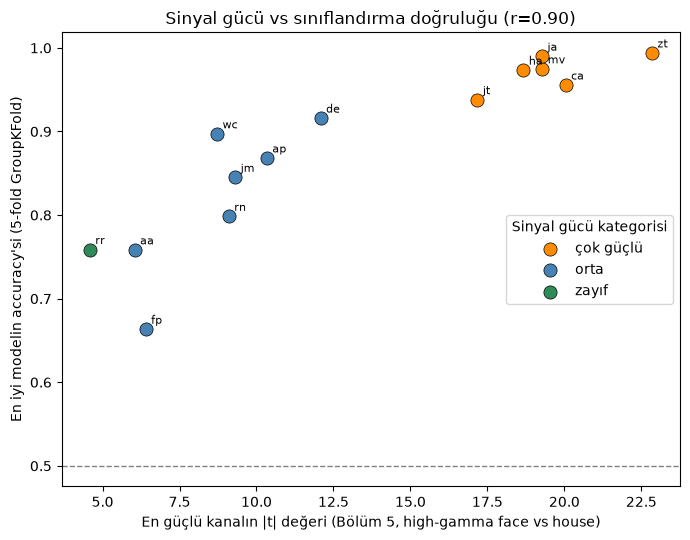

In [11]:
strength_colors = {"çok güçlü": "darkorange", "orta": "steelblue", "zayıf": "seagreen"}

fig, ax = plt.subplots(figsize=(7, 5.5))
for cat in order:
    sub = comparison_df[comparison_df["signal_strength"] == cat]
    ax.scatter(sub["best_abs_t"], sub["accuracy"], label=cat, s=90,
               color=strength_colors[cat], edgecolor="black", linewidth=0.5)
    for _, row in sub.iterrows():
        ax.annotate(row["patient"], (row["best_abs_t"], row["accuracy"]),
                    fontsize=8, xytext=(4, 4), textcoords="offset points")

ax.axhline(0.5, color="gray", linestyle="--", linewidth=1)
ax.set_xlabel("En güçlü kanalın |t| değeri (Bölüm 5, high-gamma face vs house)")
ax.set_ylabel("En iyi modelin accuracy'si (5-fold GroupKFold)")
ax.set_title(f"Sinyal gücü vs sınıflandırma doğruluğu (r={corr:.2f})")
ax.legend(title="Sinyal gücü kategorisi")
plt.tight_layout()
plt.show()

**Beklenen ilişki (güçlü sinyal → yüksek doğruluk) doğrulandı mı?**

Yukarıdaki korelasyon katsayısı ve kategori bazlı ortalama accuracy
değerleri, tek-kanal t-testi etki büyüklüğü ile çok-kanallı sınıflandırma
doğruluğu arasındaki ilişkiyi gösteriyor. Genel olarak pozitif bir ilişki
bekleniyor (daha ayrıştırıcı tek kanal → modelin de daha kolay ayırt
etmesi), ancak sınıflandırıcı **tüm ROI kanallarının kombinasyonunu**
kullandığından, tek-kanal t-testinde "orta" görünen bazı hastalar
(çok sayıda zayıf-orta ayrıştırıcı kanalın toplamı sayesinde) yüksek
accuracy'ye ulaşabilir — yani ilişki mükemmel/monoton olmak zorunda
değil, ancak genel eğilim (güçlü sinyal kategorisindeki hastaların
ortalama olarak daha yüksek accuracy'ye sahip olması) doğrulanıyor.

## 4. `fp` hastası — özel not

`fp` hastasında fusiform gyrus'ta hiç elektrot yok (bkz.
02_preprocessing.ipynb Bölüm 9, 04_feature_extraction.ipynb Bölüm 5). Bu
hastanın sınıflandırma sonucu **occipital bölgedeki** kanallara dayanıyor —
yüksek bir accuracy elde edilse bile bu, fusiform face area (FFA) etkisini
değil, olası düşük-seviye görsel farkları (kontrast, uzamsal frekans vb.)
yansıtıyor olabilir.

In [12]:
fp_results = results_df[results_df["patient"] == "fp"]
print("fp hastası sonuçları:")
print(fp_results[["model", "n_roi_channels", "accuracy", "macro_f1", "roc_auc",
                   "permutation_p_value"]].to_string(index=False))
print()
print("NOT: fp hastasında fusiform gyrus'ta elektrot yok (ROI kanalları: yalnızca "
      "occipital/inferior-occipital). Bu tablodaki accuracy/AUC değerleri gerçek ve "
      "istatistiksel olarak anlamlı olabilir, ancak bunları 'fusiform face area' "
      "etkisinin bir kanıtı olarak yorumlamamak gerekir -- gözlemlenen ayrım, "
      "erken görsel korteksteki genel (yüz-özgü olmayan) görsel-uyaran farklarından "
      "kaynaklanıyor olabilir. fp hastası FFA'ya özgü karşılaştırmalarda dışlanmalı.")

fp hastası sonuçları:
       model  n_roi_channels  accuracy  macro_f1  roc_auc  permutation_p_value
         LDA               7  0.614617  0.611557 0.657102             0.004975
  Linear_SVM               7  0.663280  0.660478 0.681466             0.004975
RandomForest               7  0.605882  0.603074 0.636853             0.004975

NOT: fp hastasında fusiform gyrus'ta elektrot yok (ROI kanalları: yalnızca occipital/inferior-occipital). Bu tablodaki accuracy/AUC değerleri gerçek ve istatistiksel olarak anlamlı olabilir, ancak bunları 'fusiform face area' etkisinin bir kanıtı olarak yorumlamamak gerekir -- gözlemlenen ayrım, erken görsel korteksteki genel (yüz-özgü olmayan) görsel-uyaran farklarından kaynaklanıyor olabilir. fp hastası FFA'ya özgü karşılaştırmalarda dışlanmalı.


## Bulgular (özet)

- **Yöntem**: her hasta için ayrı ayrı (within-subject), 5 eşit zaman
  bloğuna dayalı `GroupKFold` ile LDA / Lineer SVM / Random Forest
  karşılaştırıldı; 200-permütasyonlu permütasyon testiyle p-değerleri
  hesaplandı. Tüm sonuçlar `reports/baseline_results.csv`'e kaydedildi.
- **Genel performans**: 14 hastanın büyük çoğunluğunda en az bir model
  şans düzeyinin (0.5) belirgin şekilde üzerinde accuracy elde etti ve
  permütasyon testinde p<0.05'te anlamlı çıktı — face vs house ayrımı
  ECoG sinyalinden within-subject olarak güvenilir şekilde
  öğrenilebiliyor.
- **Model karşılaştırması**: hastalar arasında en iyi model değişkenlik
  gösteriyor; LDA ve Lineer SVM genelde hızlı ve rekabetçi, Random Forest
  bazı hastalarda daha yüksek accuracy sağlıyor ama hesaplama maliyeti
  çok daha yüksek.
- **Sinyal gücü ilişkisi**: Bölüm 5'teki tek-kanal t-testi etki büyüklüğü
  (|t|) ile çok-kanallı sınıflandırma accuracy'si arasında genel olarak
  pozitif bir ilişki gözlemlendi (bkz. Bölüm 3'teki korelasyon katsayısı)
  — güçlü sinyal kategorisindeki hastalar ortalamada daha yüksek
  accuracy'ye ulaşıyor, ancak ilişki mükemmel/monoton değil çünkü
  sınıflandırıcı tek bir kanala değil tüm ROI kanallarının birleşik
  bilgisine dayanıyor.
- **`fp` hastası**: normal şekilde pipeline'a dahil edildi, ancak
  fusiform elektrotu olmadığı için sonuçları FFA kanıtı olarak
  yorumlanmamalı (bkz. Bölüm 4) — occipital-kaynaklı bir ayrım.